# HumanForYou — Prédiction sur nouveau jeu de données

**Usage lors de la soutenance :** Ce notebook permet de tester le modèle final sur un nouveau jeu de données fourni par le jury.

**Ce dont vous avez besoin :**
- Les nouveaux fichiers CSV au même format que les données originales
- Le modèle sauvegardé dans `models/`

**Seule chose à modifier :** le chemin vers les nouveaux fichiers CSV (cellule 2).

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import joblib
import warnings

from sklearn.preprocessing import StandardScaler, LabelEncoder

warnings.filterwarnings('ignore')

---
## 1. Chargement du modèle sauvegardé

In [2]:
MODEL_PATH   = '../models/random_forest_final.pkl'
COLUMNS_PATH = '../models/feature_columns.pkl'

model           = joblib.load(MODEL_PATH)
feature_columns = joblib.load(COLUMNS_PATH)

print(f"Modèle chargé : {type(model).__name__}")
print(f"Nombre de features attendues : {len(feature_columns)}")
print(f"Features : {feature_columns}")

Modèle chargé : RandomForestClassifier
Nombre de features attendues : 43
Features : ['Age', 'DistanceFromHome', 'Education', 'Gender', 'JobLevel', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 'PerformanceRating', 'avg_hours_per_day', 'std_hours_per_day', 'days_absent', 'days_over_8h', 'avg_arrival_hour', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Research & Development', 'Department_Sales', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Exec

---
## 2. Chargement des nouveaux fichiers

**Modifiez les chemins ci-dessous** selon les fichiers fournis par le jury.

In [3]:
# ============================================================
# MODIFIER ICI : chemins vers les nouveaux fichiers CSV
# ============================================================
NEW_GENERAL  = '../data/raw/general_data.csv'           # remplacer par le nouveau fichier
NEW_SURVEY   = '../data/raw/employee_survey_data.csv'   # remplacer par le nouveau fichier
NEW_MANAGER  = '../data/raw/manager_survey_data.csv'    # remplacer par le nouveau fichier
NEW_IN_TIME  = '../data/raw/in_time.csv'                # remplacer par le nouveau fichier
NEW_OUT_TIME = '../data/raw/out_time.csv'               # remplacer par le nouveau fichier
# ============================================================

general  = pd.read_csv(NEW_GENERAL)
survey   = pd.read_csv(NEW_SURVEY)
manager  = pd.read_csv(NEW_MANAGER)
in_time  = pd.read_csv(NEW_IN_TIME,  index_col=0)
out_time = pd.read_csv(NEW_OUT_TIME, index_col=0)

print(f"general  : {general.shape}")
print(f"survey   : {survey.shape}")
print(f"manager  : {manager.shape}")
print(f"in_time  : {in_time.shape}")
print(f"out_time : {out_time.shape}")

general  : (4410, 24)
survey   : (4410, 4)
manager  : (4410, 3)
in_time  : (4410, 261)
out_time : (4410, 261)


---
## 3. Preprocessing identique au notebook 02

On applique exactement les mêmes transformations que pendant l'entraînement.

In [4]:
# --- Suppression colonnes constantes ---
for col in ['EmployeeCount', 'Over18', 'StandardHours']:
    if col in general.columns:
        general = general.drop(columns=[col])

# --- Features badgeage ---
in_dt  = in_time.apply(pd.to_datetime, errors='coerce')
out_dt = out_time.apply(pd.to_datetime, errors='coerce')
work_hours = (out_dt - in_dt).apply(lambda col: col.dt.total_seconds() / 3600)

badge = pd.DataFrame()
badge['EmployeeID']        = general['EmployeeID'].values
badge['avg_hours_per_day'] = work_hours.mean(axis=1).values
badge['std_hours_per_day'] = work_hours.std(axis=1).values
badge['days_absent']       = work_hours.isna().sum(axis=1).values
badge['days_over_8h']      = (work_hours > 8).sum(axis=1).values
badge['avg_arrival_hour']  = in_dt.apply(
    lambda col: col.dt.hour + col.dt.minute / 60).mean(axis=1).values

# --- Fusion ---
df = general.merge(survey,  on='EmployeeID', how='left')
df = df.merge(manager, on='EmployeeID', how='left')
df = df.merge(badge,   on='EmployeeID', how='left')

# Sauvegarder EmployeeID pour l'output final
employee_ids = df['EmployeeID'].copy()

# Sauvegarder Attrition si présente (pour évaluation)
has_target = 'Attrition' in df.columns
if has_target:
    y_true = (df['Attrition'] == 'Yes').astype(int)
    df = df.drop(columns=['Attrition'])

# --- Imputation médiane ---
num_cols = df.select_dtypes(include='number').columns.tolist()
for col in num_cols:
    if df[col].isna().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# --- Encodage ---
le = LabelEncoder()
if 'Gender' in df.columns:
    df['Gender'] = le.fit_transform(df['Gender'])

ohe_cols = ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']
df = pd.get_dummies(df, columns=[c for c in ohe_cols if c in df.columns], drop_first=True)

# --- Alignement des colonnes (ajouter les colonnes manquantes à 0) ---
X = df.drop(columns=['EmployeeID'], errors='ignore')
for col in feature_columns:
    if col not in X.columns:
        X[col] = 0
X = X[feature_columns]  # ordre exact attendu par le modèle

# --- Normalisation ---
ohe_generated = [c for c in X.columns if any(c.startswith(b + '_') for b in
                 ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus'])]
cols_a_normaliser = [c for c in X.select_dtypes(include='number').columns
                     if c not in ohe_generated]

scaler = StandardScaler()
X[cols_a_normaliser] = scaler.fit_transform(X[cols_a_normaliser])

print(f"Données prêtes : {X.shape}")
print(f"Colonnes OK : {list(X.columns) == feature_columns}")

Données prêtes : (4410, 43)
Colonnes OK : True


---
## 4. Prédictions

In [5]:
y_pred  = model.predict(X)
y_proba = model.predict_proba(X)[:, 1]

resultats = pd.DataFrame({
    'EmployeeID'           : employee_ids.values,
    'Probabilite_depart'   : y_proba.round(4),
    'Prediction'           : ['Part' if p == 1 else 'Reste' for p in y_pred],
})

print(f"Nombre d'employés analysés : {len(resultats)}")
print(f"Prédits comme partants     : {(y_pred == 1).sum()} ({(y_pred == 1).mean()*100:.1f}%)")
print()
resultats.head(20)

Nombre d'employés analysés : 4410
Prédits comme partants     : 686 (15.6%)



,EmployeeID,Probabilite_depart,Prediction
0,1,0.0340,Reste
1,2,0.9315,Part
2,3,0.0774,Reste
3,4,0.0133,Reste
4,5,0.0563,Reste
5,6,0.0735,Reste
6,7,0.8198,Part
7,8,0.1207,Reste
8,9,0.0242,Reste
9,10,0.0329,Reste


---
## 5. Évaluation (si la variable Attrition est fournie dans le jeu de test)

=== Résultats sur le jeu de test fourni ===
              precision    recall  f1-score   support

       Reste       0.99      1.00      1.00      3699
        Part       1.00      0.96      0.98       711

    accuracy                           0.99      4410
   macro avg       1.00      0.98      0.99      4410
weighted avg       0.99      0.99      0.99      4410

AUC-ROC : 0.9992


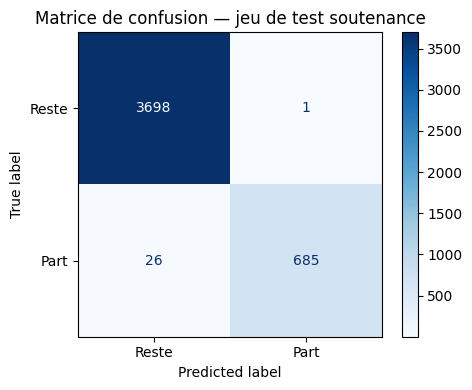

In [6]:
if has_target:
    from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
    import matplotlib.pyplot as plt

    print("=== Résultats sur le jeu de test fourni ===")
    print(classification_report(y_true, y_pred, target_names=['Reste', 'Part']))
    print(f"AUC-ROC : {roc_auc_score(y_true, y_proba):.4f}")

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        display_labels=['Reste', 'Part'],
        cmap='Blues', ax=ax
    )
    plt.title('Matrice de confusion — jeu de test soutenance')
    plt.tight_layout()
    plt.show()
else:
    print("Pas de colonne Attrition dans le jeu de test → pas d'évaluation possible.")
    print("Les prédictions sont disponibles dans le tableau ci-dessus.")

---
## 6. Export des prédictions en CSV

In [7]:
resultats.to_csv('../outputs/predictions_soutenance.csv', index=False)
print("Prédictions exportées : outputs/predictions_soutenance.csv")
resultats.sort_values('Probabilite_depart', ascending=False).head(10)

Prédictions exportées : outputs/predictions_soutenance.csv


,EmployeeID,Probabilite_depart,Prediction
473,474,0.9907,Part
3413,3414,0.9851,Part
4014,4015,0.9749,Part
634,635,0.9741,Part
2544,2545,0.9741,Part
2272,2273,0.9738,Part
1015,1016,0.9713,Part
3593,3594,0.9708,Part
1074,1075,0.9699,Part
2224,2225,0.9668,Part
